# TFT Forecaster v2.1 + Optuna

1. Data prep (v2 config + `days_after_christmas`)
2. Build TimeSeriesDataSet
3. **Optuna hyperparameter search** (~15 trials × ~1 min each)
4. Full training with best hyperparameters
5. Predict → Submission → Plot → Export

**Run cells top-to-bottom.**

In [1]:
# Cell 1: Imports & GPU check
import os, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer, NaNLabelEncoder
from pytorch_forecasting.metrics import MAE
import optuna
from optuna.integration import PyTorchLightningPruningCallback

pl.seed_everything(42, workers=True)
print(f'PyTorch : {torch.__version__}')
print(f'Lightning: {pl.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'  Device : {torch.cuda.get_device_name(0)}')
    torch.set_float32_matmul_precision('medium')
else:
    print('No GPU detected.')

Seed set to 42


PyTorch : 2.9.1+cu130
Lightning: 2.6.5
CUDA     : True
  Device : NVIDIA GeForce RTX 5080


## 1. Data Preparation

In [2]:
# Cell 2: Data prep
TRAIN_PATH  = 'train.csv'
EVENTS_PATH = 'calendar_events.csv'
train  = pd.read_csv(TRAIN_PATH, parse_dates=['date'])
events = pd.read_csv(EVENTS_PATH, parse_dates=['date'])
FORECAST_START = pd.Timestamp('2015-10-01')
FORECAST_END   = pd.Timestamp('2015-12-31')
HORIZON = (FORECAST_END - FORECAST_START).days + 1
print(f'Horizon: {HORIZON} days')

events['event'] = events['event'].str.split(',').str[0].str.strip()
events_map = dict(zip(events['date'], events['event']))
STATE_MAP = {'0':'ALL','1':'CA','2':'CA','3':'CA','4':'CA','5':'TX','6':'TX','7':'TX','8':'WI','9':'WI','10':'WI'}
CHRISTMAS_2015 = pd.Timestamp('2015-12-25')

date_min  = train['date'].min()
all_dates = pd.date_range(date_min, FORECAST_END, freq='D')
all_stores = sorted(train['store_id'].unique())
grid = pd.MultiIndex.from_product([all_stores, all_dates], names=['store_id','date']).to_frame(index=False)
df = grid.merge(train[['store_id','date','revenue']], on=['store_id','date'], how='left')

df['dow']        = df['date'].dt.dayofweek.astype(str)
df['month']      = df['date'].dt.month.astype(str)
df['day']        = df['date'].dt.day.astype(np.float32)
df['week']       = df['date'].dt.isocalendar().week.astype(np.float32)
df['is_weekend'] = (df['date'].dt.dayofweek >= 5).astype(np.float32)
df['event']      = df['date'].map(events_map).fillna('none').astype(str)
df['is_event']   = (df['event'] != 'none').astype(np.float32)

def days_to_holiday(date_series, hm, hd):
    years = date_series.dt.year
    holidays = pd.to_datetime(years.astype(str) + f'-{hm:02d}-{hd:02d}', errors='coerce')
    return (holidays - date_series).dt.days.astype(np.float32).clip(lower=-30, upper=60)

df['days_to_christmas']    = days_to_holiday(df['date'], 12, 25)
df['days_to_thanksgiving'] = days_to_holiday(df['date'], 11, 25)

def days_after_christmas(date_series):
    years = date_series.dt.year
    christmas = pd.to_datetime(years.astype(str) + '-12-25', errors='coerce')
    delta = (date_series - christmas).dt.days.astype(np.float32)
    prior = pd.to_datetime((years - 1).astype(str) + '-12-25', errors='coerce')
    delta_prior = (date_series - prior).dt.days.astype(np.float32)
    result = np.where(delta >= 0, delta, delta_prior)
    return np.clip(result, 0, 30).astype(np.float32)

df['days_after_christmas'] = days_after_christmas(df['date'])
df['time_idx'] = (df['date'] - date_min).dt.days.astype(np.int64)
df['store_id'] = df['store_id'].astype(str)
df['state']    = df['store_id'].map(STATE_MAP)

mask_past = df['date'] < FORECAST_START
df.loc[mask_past, 'revenue'] = df.loc[mask_past].groupby('store_id')['revenue'].transform(lambda s: s.ffill().bfill())
df['revenue'] = df['revenue'].fillna(0.0).astype(np.float32)
print(f'Grid: {len(df):,} rows')

Horizon: 92 days
Grid: 19,778 rows


## 2. Build TimeSeriesDataSet

In [3]:
# Cell 3: Dataset
MAX_ENCODER_LENGTH    = 180  # shorter encoder for fast Optuna trials
MAX_PREDICTION_LENGTH = HORIZON
training_cutoff = int(df.loc[df['date'] == FORECAST_START - pd.Timedelta(days=1), 'time_idx'].iloc[0])

training = TimeSeriesDataSet(
    df[df['time_idx'] <= training_cutoff],
    time_idx='time_idx', target='revenue', group_ids=['store_id'],
    max_encoder_length=MAX_ENCODER_LENGTH, min_encoder_length=MAX_ENCODER_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH, min_prediction_length=MAX_PREDICTION_LENGTH,
    static_categoricals=['store_id', 'state'],
    time_varying_known_categoricals=['event', 'dow', 'month'],
    time_varying_known_reals=['time_idx','is_event','is_weekend','day','week',
                              'days_to_christmas','days_to_thanksgiving','days_after_christmas'],
    time_varying_unknown_reals=['revenue'],
    target_normalizer=GroupNormalizer(groups=['store_id'], transformation='softplus'),
    categorical_encoders={'event':NaNLabelEncoder(add_nan=True),'dow':NaNLabelEncoder(add_nan=True),
                          'month':NaNLabelEncoder(add_nan=True),'state':NaNLabelEncoder(add_nan=True)},
    add_relative_time_idx=True, add_target_scales=True, add_encoder_length=True,
    allow_missing_timesteps=False,
)
validation = TimeSeriesDataSet.from_dataset(training, df, predict=True, stop_randomization=True)

BATCH_SIZE = 128
train_dataloader = training.to_dataloader(train=True,  batch_size=BATCH_SIZE, num_workers=0)
val_dataloader   = validation.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)
print(f'Training samples: {len(training):,}')

Training samples: 15,785


## 3. Optuna Hyperparameter Search

Runs 15 trials, each training for 5 epochs (~1 min per trial).
Searches over: `learning_rate`, `hidden_size`, `dropout`, `attention_head_size`.

In [4]:
# Cell 4: Optuna search with progress
import time as _time

N_TRIALS = 15
_trial_start_times = {}

def objective(trial):
    _trial_start_times[trial.number] = _time.time()
    print(f'\n{"="*60}')
    print(f'  Trial {trial.number + 1}/{N_TRIALS} starting...')
    print(f'{"="*60}')

    lr = trial.suggest_float('learning_rate', 5e-4, 3e-3, log=True)
    hidden = trial.suggest_categorical('hidden_size', [64, 96, 128])
    dropout = trial.suggest_float('dropout', 0.05, 0.25, step=0.05)
    heads = trial.suggest_categorical('attention_head_size', [2, 4])

    print(f'  Params: lr={lr:.5f}, hidden={hidden}, dropout={dropout:.2f}, heads={heads}')

    tft_trial = TemporalFusionTransformer.from_dataset(
        training, learning_rate=lr, hidden_size=hidden,
        attention_head_size=heads, dropout=dropout,
        hidden_continuous_size=32, output_size=1, loss=MAE(),
        log_interval=-1, reduce_on_plateau_patience=2,
    )

    trainer_trial = pl.Trainer(
        max_epochs=5, accelerator='auto', devices=1,
        gradient_clip_val=0.1, enable_progress_bar=True,
        enable_model_summary=False,
        callbacks=[PyTorchLightningPruningCallback(trial, monitor='val_loss')],
    )

    trainer_trial.fit(tft_trial, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)
    val_loss = trainer_trial.callback_metrics['val_loss'].item()

    elapsed = _time.time() - _trial_start_times[trial.number]
    print(f'  Result: val_loss={val_loss:.4f} (took {elapsed:.1f}s)')
    return val_loss

print(f'Starting Optuna search: {N_TRIALS} trials, 5 epochs each')
print(f'Search space: lr=[5e-4..3e-3], hidden=[64,96,128], dropout=[0.05..0.25], heads=[2,4]')
print()

study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=N_TRIALS, timeout=900)

print(f'\n{"="*60}')
print(f'  SEARCH COMPLETE')
print(f'  Best trial: #{study.best_trial.number + 1}')
print(f'  Best val_loss: {study.best_trial.value:.4f}')
print(f'  Best params: {study.best_trial.params}')
print(f'{"="*60}')
best_params = study.best_trial.params

[I 2026-06-14 14:29:31,803] A new study created in memory with name: no-name-b8f72a6a-a428-44cb-b8b2-5479b360b094


Starting Optuna search: 15 trials, 5 epochs each
Search space: lr=[5e-4..3e-3], hidden=[64,96,128], dropout=[0.05..0.25], heads=[2,4]


  Trial 1/15 starting...
  Params: lr=0.00069, hidden=128, dropout=0.20, heads=4


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=5` reached.


[I 2026-06-14 14:32:42,049] Trial 0 finished with value: 52338.6875 and parameters: {'learning_rate': 0.0006923897762571629, 'hidden_size': 128, 'dropout': 0.2, 'attention_head_size': 4}. Best is trial 0 with value: 52338.6875.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  Result: val_loss=52338.6875 (took 190.2s)

  Trial 2/15 starting...
  Params: lr=0.00067, hidden=96, dropout=0.15, heads=4


...

`Trainer.fit` stopped: `max_epochs=5` reached.


[I 2026-06-14 14:44:23,315] Trial 4 finished with value: 53985.66015625 and parameters: {'learning_rate': 0.0007716251082653201, 'hidden_size': 128, 'dropout': 0.2, 'attention_head_size': 4}. Best is trial 3 with value: 51796.3125.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  Result: val_loss=53985.6602 (took 177.6s)

  Trial 6/15 starting...
  Params: lr=0.00062, hidden=96, dropout=0.20, heads=2


[I 2026-06-14 14:44:57,906] Trial 5 pruned. Trial was pruned at epoch 0.



  SEARCH COMPLETE
  Best trial: #4
  Best val_loss: 51796.3125
  Best params: {'learning_rate': 0.0006112307162657746, 'hidden_size': 96, 'dropout': 0.25, 'attention_head_size': 4}


## 4. Full Training with Best Hyperparameters

In [5]:
# Cell 5: Full train with best params
# Rebuild dataset with full 365-day encoder for final training
MAX_ENCODER_LENGTH_FULL = 365

training_full = TimeSeriesDataSet(
    df[df['time_idx'] <= training_cutoff],
    time_idx='time_idx', target='revenue', group_ids=['store_id'],
    max_encoder_length=MAX_ENCODER_LENGTH_FULL, min_encoder_length=MAX_ENCODER_LENGTH_FULL,
    max_prediction_length=MAX_PREDICTION_LENGTH, min_prediction_length=MAX_PREDICTION_LENGTH,
    static_categoricals=['store_id', 'state'],
    time_varying_known_categoricals=['event', 'dow', 'month'],
    time_varying_known_reals=['time_idx','is_event','is_weekend','day','week',
                              'days_to_christmas','days_to_thanksgiving','days_after_christmas'],
    time_varying_unknown_reals=['revenue'],
    target_normalizer=GroupNormalizer(groups=['store_id'], transformation='softplus'),
    categorical_encoders={'event':NaNLabelEncoder(add_nan=True),'dow':NaNLabelEncoder(add_nan=True),
                          'month':NaNLabelEncoder(add_nan=True),'state':NaNLabelEncoder(add_nan=True)},
    add_relative_time_idx=True, add_target_scales=True, add_encoder_length=True,
    allow_missing_timesteps=False,
)
validation_full = TimeSeriesDataSet.from_dataset(training_full, df, predict=True, stop_randomization=True)

train_dl_full = training_full.to_dataloader(train=True,  batch_size=64, num_workers=0)
val_dl_full   = validation_full.to_dataloader(train=False, batch_size=64, num_workers=0)

early_stop = EarlyStopping(monitor='val_loss', min_delta=1e-4, patience=10, mode='min')
lr_monitor = LearningRateMonitor(logging_interval='epoch')

trainer_final = pl.Trainer(
    max_epochs=50, accelerator='auto', devices=1,
    gradient_clip_val=0.1, callbacks=[early_stop, lr_monitor],
    enable_progress_bar=True, log_every_n_steps=20,
)

tft_final = TemporalFusionTransformer.from_dataset(
    training_full,
    learning_rate=best_params['learning_rate'],
    hidden_size=best_params['hidden_size'],
    attention_head_size=best_params['attention_head_size'],
    dropout=best_params['dropout'],
    hidden_continuous_size=64, output_size=1, loss=MAE(),
    log_interval=20, reduce_on_plateau_patience=3,
)
print(f'Final TFT params: {sum(p.numel() for p in tft_final.parameters()):,}')
print(f'Using: {best_params}')

trainer_final.fit(tft_final, train_dataloaders=train_dl_full, val_dataloaders=val_dl_full)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Final TFT params: 955,847
Using: {'learning_rate': 0.0006112307162657746, 'hidden_size': 96, 'dropout': 0.25, 'attention_head_size': 4}


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ MAE                             │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    569 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  1.7 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 65.9 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  225 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  202 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 37.4 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 37.4 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 37.4 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 37.4 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 74.5 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 74.5 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │ 18.6 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    192 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 46.7 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 23.3 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │ 18.8 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 37.4 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │ 18.8 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     97 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 955 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 955 K                                                                                                
Total estimated model params size (MB): 3.823                                                                      
Modules in train mode: 519                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

## 5. Predict

In [6]:
# Cell 6: Predict
best_ckpt = trainer_final.checkpoint_callback.best_model_path if trainer_final.checkpoint_callback else ''
if best_ckpt:
    print(f'Loading: {best_ckpt}')
    best_tft = TemporalFusionTransformer.load_from_checkpoint(best_ckpt)
else:
    best_tft = tft_final

out = best_tft.predict(val_dl_full, mode='prediction', return_x=True, return_index=True)
preds = out.output.cpu().numpy()
if preds.ndim == 3: preds = preds.squeeze(-1)
index = out.index.reset_index(drop=True)
print(f'Predictions shape: {preds.shape}')

Loading: C:\Users\Guy\Documents\M.S. MLDS\Advanced ML\FinalProject\AdvancedML_Project\DeepLearning\lightning_logs\version_13\checkpoints\epoch=15-step=3424.ckpt


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predictions shape: (11, 92)


## 6. Build Submission

In [7]:
# Cell 7: Submission
records = []
for i, row in index.iterrows():
    store_id = row['store_id']
    start_idx = int(row['time_idx'])
    for j in range(preds.shape[1]):
        date = date_min + pd.Timedelta(days=start_idx + j)
        records.append({'store_id': store_id, 'date': date, 'prediction': float(preds[i, j])})

submission_long = pd.DataFrame(records)
submission_long['prediction'] = submission_long['prediction'].clip(lower=0)
submission_long.loc[submission_long['date'] == CHRISTMAS_2015, 'prediction'] = 0.0

submission = submission_long.copy()
submission['id'] = submission['store_id'].astype(str) + '_' + submission['date'].dt.strftime('%Y%m%d')
submission = submission[['id', 'prediction']]
print(f'Rows: {len(submission)}')

Rows: 1012


## 7. Plots

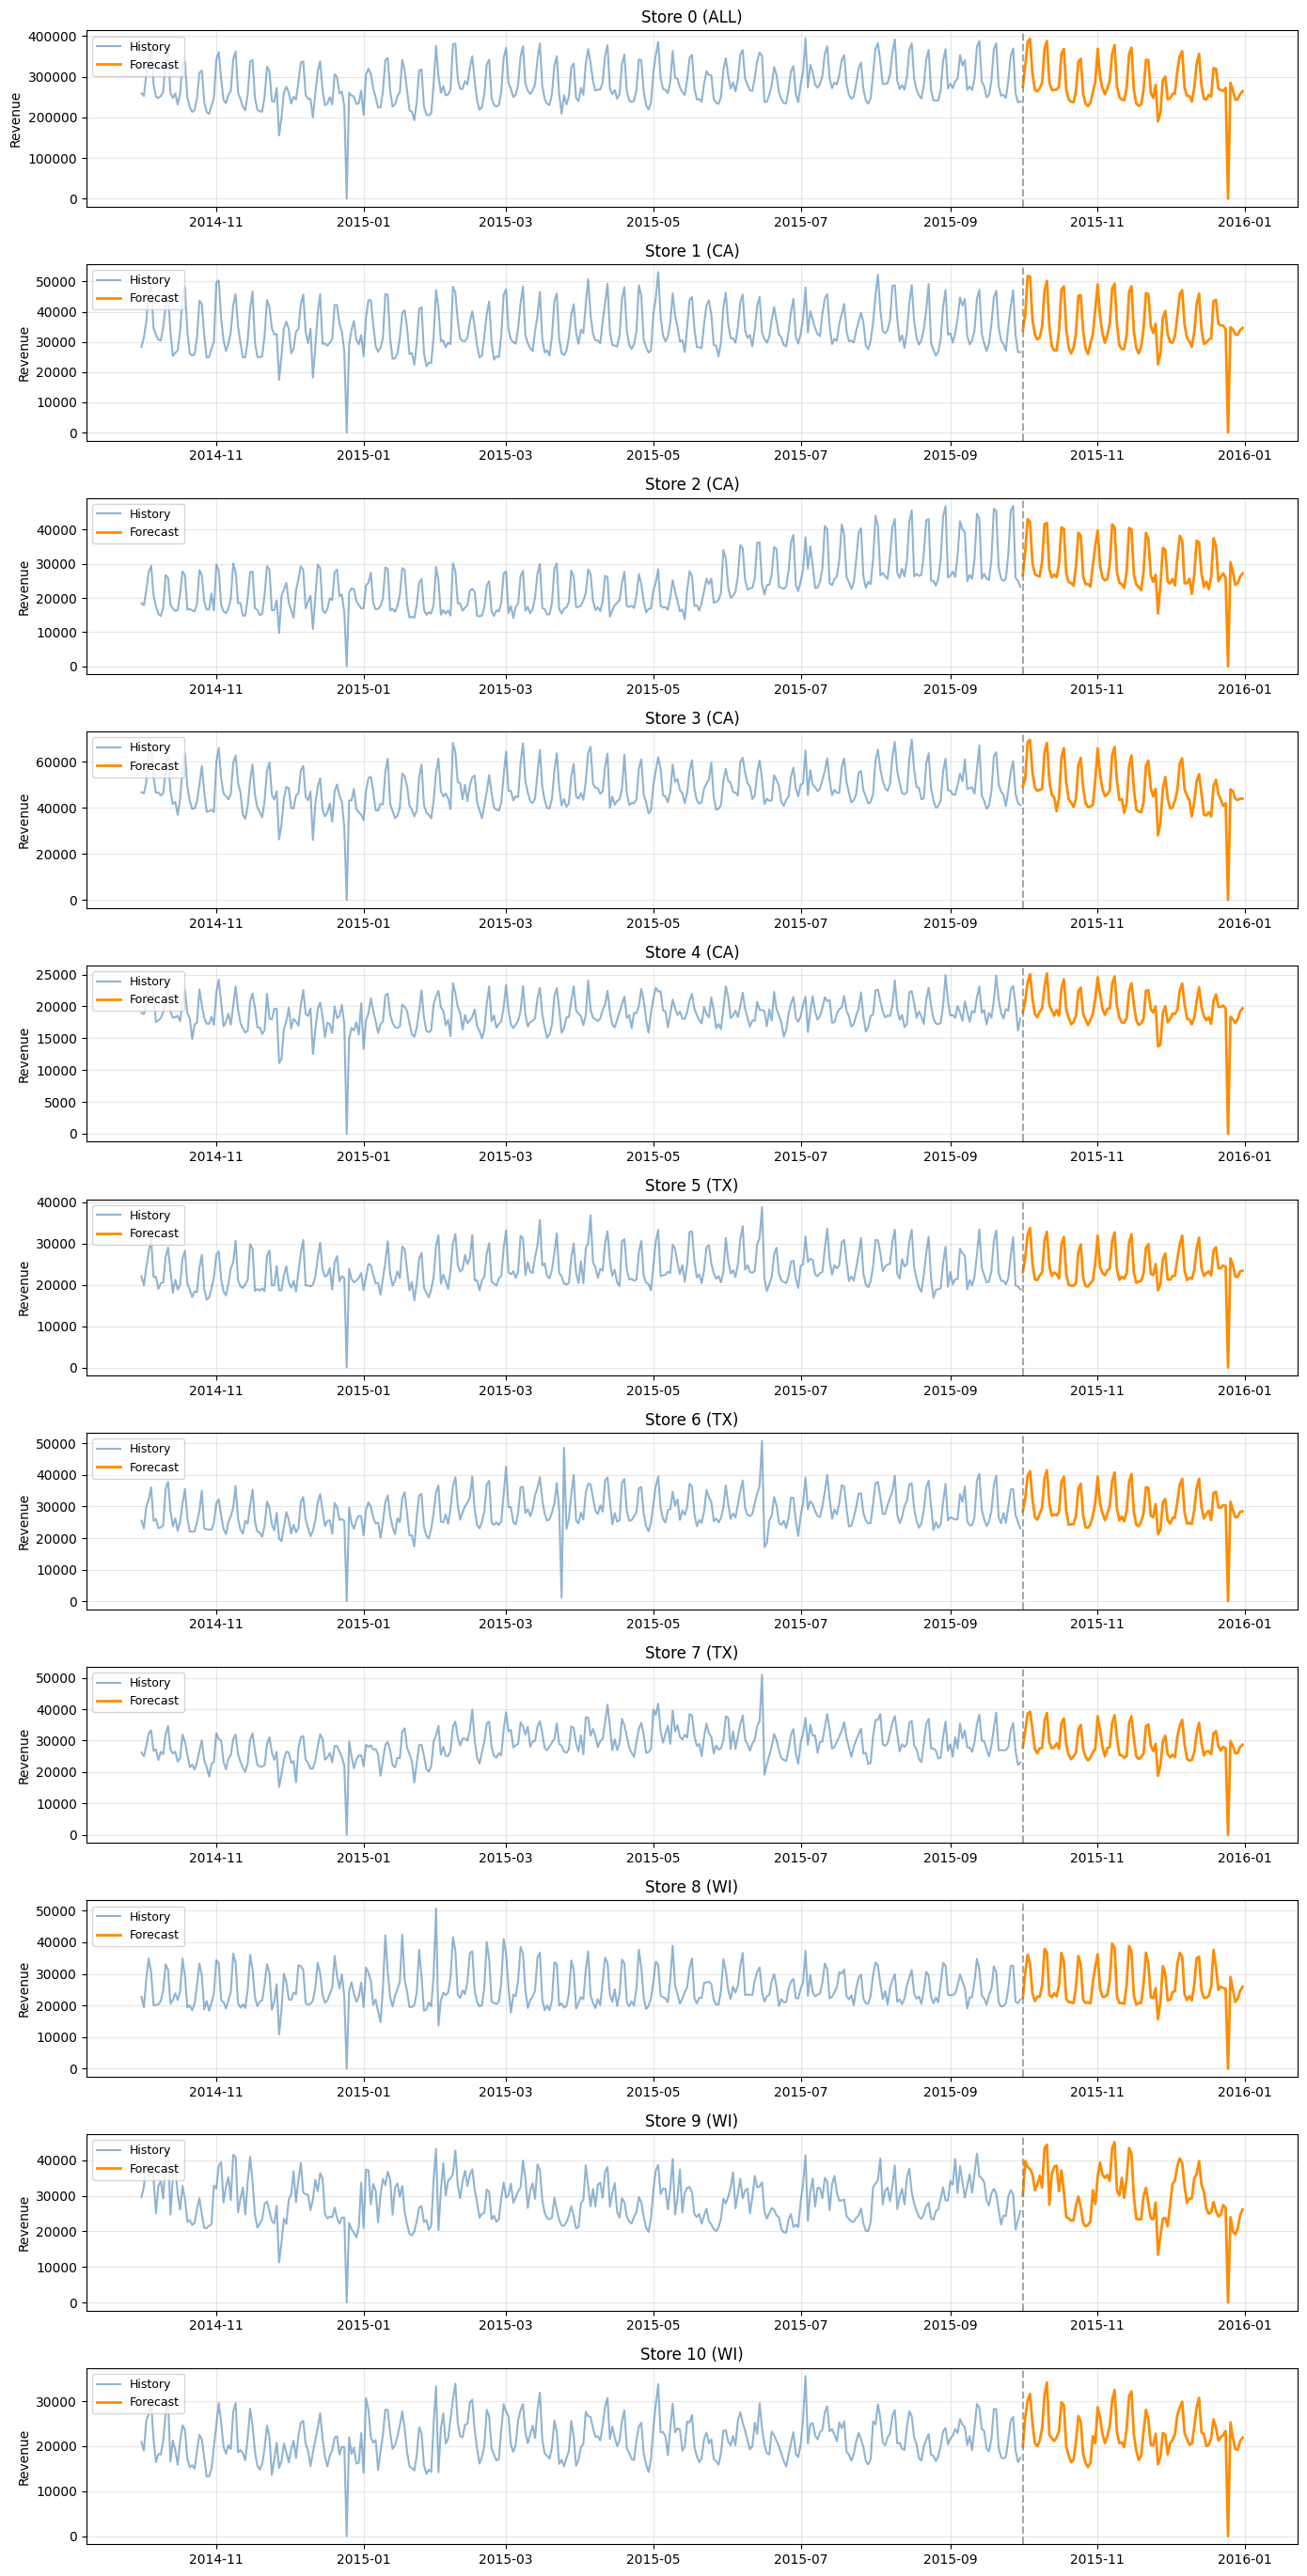

In [8]:
# Cell 8: Plot
RESULTS_DIR = 'Results'
os.makedirs(RESULTS_DIR, exist_ok=True)
n = len(all_stores)
fig, axes = plt.subplots(n, 1, figsize=(14, 2.5*n), sharex=False)
if n == 1: axes = [axes]
history_window = pd.Timedelta(days=365)
for ax, store_id in zip(axes, all_stores):
    s = str(store_id)
    hist = df[(df['store_id']==s)&(df['date']<FORECAST_START)&(df['date']>=FORECAST_START-history_window)]
    ax.plot(hist['date'], hist['revenue'], color='steelblue', alpha=0.6, label='History')
    pred = submission_long[submission_long['store_id']==s].sort_values('date')
    ax.plot(pred['date'], pred['prediction'], color='darkorange', linewidth=2, label='Forecast')
    ax.axvline(FORECAST_START, linestyle='--', color='gray', alpha=0.7)
    ax.set_title(f'Store {store_id} ({STATE_MAP.get(s,"")})')
    ax.set_ylabel('Revenue'); ax.grid(True, alpha=0.3); ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,'forecast_plots.png'), dpi=120, bbox_inches='tight')
plt.show()

## 8. Export

In [9]:
# Cell 9: Export
submission.to_csv(os.path.join(RESULTS_DIR,'forecast_submission.csv'), index=False)
submission_long.to_csv(os.path.join(RESULTS_DIR,'forecast_predictions_long.csv'), index=False)
print('Done.')

Done.
